In [22]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

df = pd.read_csv("ecommerce_customer_behavior_dataset.csv")

df.head()

,Order_ID,Customer_ID,Date,Age,Gender,City,Product_Category,Unit_Price,Quantity,Discount_Amount,Total_Amount,Payment_Method,Device_Type,Session_Duration_Minutes,Pages_Viewed,Is_Returning_Customer,Delivery_Time_Days,Customer_Rating
0,ORD_001337,CUST_01337,2023-01-01,27,Female,Bursa,Toys,54.28,1,0.00,54.28,Debit Card,Mobile,4,14,True,8,5
1,ORD_004885,CUST_04885,2023-01-01,42,Male,Konya,Toys,244.90,1,0.00,244.90,Credit Card,Mobile,11,3,True,3,3
2,ORD_004507,CUST_04507,2023-01-01,43,Female,Ankara,Food,48.15,5,0.00,240.75,Credit Card,Mobile,7,8,True,5,2
3,ORD_000645,CUST_00645,2023-01-01,32,Male,Istanbul,Electronics,804.06,1,229.28,574.78,Credit Card,Mobile,8,10,False,1,4
4,ORD_000690,CUST_00690,2023-01-01,40,Female,Istanbul,Sports,755.61,5,0.00,3778.05,Cash on Delivery,Desktop,21,10,True,7,4


In [23]:
print("Dataset Shape:", df.shape)
print("\nMissing Values:")
print(df.isnull().sum())

print("\nDuplicate Rows:", df.duplicated().sum())
print("Unique Customers:", df["Customer_ID"].nunique())

Dataset Shape: (5000, 18)

Missing Values:
Order_ID                    0
Customer_ID                 0
Date                        0
Age                         0
Gender                      0
City                        0
Product_Category            0
Unit_Price                  0
Quantity                    0
Discount_Amount             0
Total_Amount                0
Payment_Method              0
Device_Type                 0
Session_Duration_Minutes    0
Pages_Viewed                0
Is_Returning_Customer       0
Delivery_Time_Days          0
Customer_Rating             0
dtype: int64

Duplicate Rows: 0
Unique Customers: 5000


In [24]:
df["Date"] = pd.to_datetime(df["Date"])

df = df.drop_duplicates()

df = df.sort_values(
    by=["Customer_ID", "Date"]
).reset_index(drop=True)

In [25]:
df["Rolling_Session_Duration"] = (
    df.groupby("Customer_ID")["Session_Duration_Minutes"]
      .transform(lambda x: x.rolling(window=3, min_periods=1).mean())
)

df["Rolling_Pages_Viewed"] = (
    df.groupby("Customer_ID")["Pages_Viewed"]
      .transform(lambda x: x.rolling(window=3, min_periods=1).mean())
)

df["Rolling_Amount"] = (
    df.groupby("Customer_ID")["Total_Amount"]
      .transform(lambda x: x.rolling(window=3, min_periods=1).mean())
)

df["Session_Number"] = df.groupby("Customer_ID").cumcount() + 1

In [26]:
df["Session_Score"] = (
    df["Rolling_Session_Duration"].rank(pct=True)
)

df["Page_Score"] = (
    df["Rolling_Pages_Viewed"].rank(pct=True)
)

df["Purchase_Score"] = (
    df["Rolling_Amount"].rank(pct=True)
)

df["Frequency_Score"] = (
    df["Session_Number"].rank(pct=True)
)

df["Dynamic_Engagement_Score"] = (
    0.35 * df["Session_Score"] +
    0.35 * df["Page_Score"] +
    0.20 * df["Purchase_Score"] +
    0.10 * df["Frequency_Score"]
) * 100

In [27]:
customer_engagement = df.groupby("Customer_ID").agg(
    Average_Session_Duration=("Session_Duration_Minutes", "mean"),
    Average_Pages_Viewed=("Pages_Viewed", "mean"),
    Purchase_Frequency=("Order_ID", "count"),
    Total_Spending=("Total_Amount", "sum"),
    Average_Engagement_Score=("Dynamic_Engagement_Score", "mean")
).reset_index()

customer_engagement.head()

,Customer_ID,Average_Session_Duration,Average_Pages_Viewed,Purchase_Frequency,Total_Spending,Average_Engagement_Score
0,CUST_00001,8.0,9.0,1,219.32,39.4040
1,CUST_00002,3.0,8.0,1,332.34,29.5025
2,CUST_00003,9.0,5.0,1,66.44,20.1920
3,CUST_00004,9.0,6.0,1,112.65,24.7540
4,CUST_00005,13.0,7.0,1,349.45,41.5200


In [28]:
cluster_columns = [
    "Average_Session_Duration",
    "Average_Pages_Viewed",
    "Purchase_Frequency",
    "Total_Spending",
    "Average_Engagement_Score"
]

scaler = StandardScaler()

scaled_data = scaler.fit_transform(
    customer_engagement[cluster_columns]
)

In [29]:
kmeans = KMeans(
    n_clusters=3,
    random_state=42,
    n_init=10
)

customer_engagement["Cluster"] = kmeans.fit_predict(scaled_data)

In [30]:
cluster_order = (
    customer_engagement.groupby("Cluster")
    ["Average_Engagement_Score"]
    .mean()
    .sort_values()
    .index
)

cluster_names = {
    cluster_order[0]: "Low Engagement",
    cluster_order[1]: "Medium Engagement",
    cluster_order[2]: "High Engagement"
}

customer_engagement["Engagement_Level"] = (
    customer_engagement["Cluster"].map(cluster_names)
)

customer_engagement[
    ["Customer_ID", "Average_Engagement_Score", "Engagement_Level"]
].head()

,Customer_ID,Average_Engagement_Score,Engagement_Level
0,CUST_00001,39.4040,Low Engagement
1,CUST_00002,29.5025,Low Engagement
2,CUST_00003,20.1920,Low Engagement
3,CUST_00004,24.7540,Low Engagement
4,CUST_00005,41.5200,Low Engagement


In [31]:
engagement_threshold = customer_engagement[
    "Average_Engagement_Score"
].quantile(0.75)

print("High Engagement Threshold:", round(engagement_threshold, 2))

High Engagement Threshold: 61.17


In [32]:
customer_engagement["Highly_Engaged"] = np.where(
    (
        customer_engagement["Average_Engagement_Score"]
        >= engagement_threshold
    )
    &
    (
        customer_engagement["Engagement_Level"]
        == "High Engagement"
    ),
    1,
    0
)

customer_engagement[
    [
        "Customer_ID",
        "Average_Engagement_Score",
        "Engagement_Level",
        "Highly_Engaged"
    ]
].head(10)

,Customer_ID,Average_Engagement_Score,Engagement_Level,Highly_Engaged
0,CUST_00001,39.4040,Low Engagement,0
1,CUST_00002,29.5025,Low Engagement,0
2,CUST_00003,20.1920,Low Engagement,0
3,CUST_00004,24.7540,Low Engagement,0
4,CUST_00005,41.5200,Low Engagement,0
5,CUST_00006,52.4455,High Engagement,0
6,CUST_00007,69.0760,High Engagement,1
7,CUST_00008,40.8535,Low Engagement,0
8,CUST_00009,24.9780,Low Engagement,0
9,CUST_00010,59.8015,High Engagement,0


In [33]:
df = df.merge(
    customer_engagement[
        [
            "Customer_ID",
            "Engagement_Level",
            "Highly_Engaged"
        ]
    ],
    on="Customer_ID",
    how="left"
)

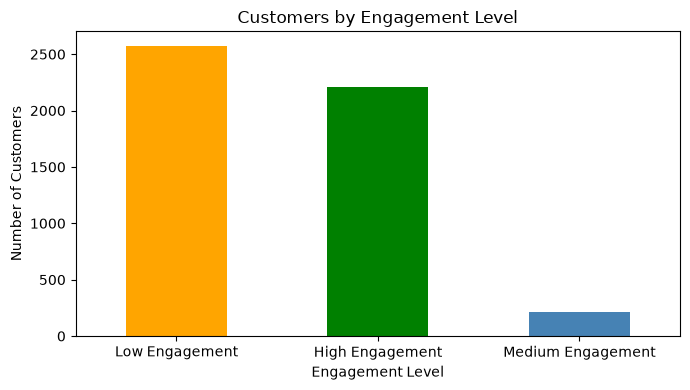

In [34]:
engagement_counts = customer_engagement[
    "Engagement_Level"
].value_counts()

engagement_counts.plot(
    kind="bar",
    color=["orange", "green", "steelblue"],
    figsize=(7, 4)
)

plt.title("Customers by Engagement Level")
plt.xlabel("Engagement Level")
plt.ylabel("Number of Customers")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

In [35]:
df.to_csv(
    "ecommerce_dynamic_engagement_results.csv",
    index=False
)

customer_engagement.to_csv(
    "customer_engagement_summary.csv",
    index=False
)

print("Results saved successfully.")

Results saved successfully.
